## Imports and Dependencies
### General Side Note: Runtime of 20-25 min
The runtime for this code in its entirety is about 20-25 minutes on my PC. 

While this is not ideal, I found that the combination of number of replicates, reasonable runtime, and achieving an appropriate uncertanity value was not possible without removing parts of the experiment. I have hopefully provided an example of the already ran code in the below notebook. Hopefully this allows for grading without running any of the lengthy pieces, but my apologies to the grader. 

In [1]:
from pathlib import Path
from copy import copy

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.stats as stats

from module_libraries.my_stats import half_frame, my_fontsize
from module_libraries.models_lib import (
    calculate_ising_energy,
    ising_dynamics,
    run_dynamics
)

## Global simulation parameters

In [2]:
L               = 20    # lattice side length
T_CRITICAL      = 2.269 # known 2D Ising critical temperature
J               = 1.0   # ferromagnetic coupling (herding tendency)
REPLICATES      = 5     # independent runs per condition → enables error bars
EQUIL_TIME      = 50    # MC steps to reach equilibrium before measuring
RUN_TIME        = 200   # MC steps of production run

# Temperature arrays
TEMPS_FULL     = np.arange(1.8, 2.71, 0.1)  # broad sweep for susceptibility/volatility plots

# External field values
FIELDS         = [0.0, 0.5, 1.0]

# Temperatures used in external-field experiments
TEMPS_FIELD    = [1.8, 2.269, 3.0]

print(f"  Lattice: {L}x{L} = {L**2} traders")
print(f"  T_critical = {T_CRITICAL}")
print(f"  Replicates per condition: {REPLICATES}")
print(f"  Equilibration / Production steps: {EQUIL_TIME} / {RUN_TIME}")

  Lattice: 20x20 = 400 traders
  T_critical = 2.269
  Replicates per condition: 5
  Equilibration / Production steps: 50 / 200


## Helper Functions

In [3]:
# Helper: initialize a random spin canvas
def init_canvas(L):
    """Return an (L x L) array of random spins in {-1, +1}."""
    canvas = stats.randint.rvs(0, 2, size=L * L).reshape((L, L))
    canvas[canvas == 0] = -1
    return canvas


# Helper: equilibrate then run production, return magnetization series
def simulate(L, T, J=1.0, equil_time=EQUIL_TIME, run_time=RUN_TIME):
    """
    Initialise a random canvas, equilibrate, then run production.
    Returns (energies, magnetizations) from the production run only.
    Magnetization is normalised per spin: M(t) / L^2.
    """
    canvas = init_canvas(L)
    energy = calculate_ising_energy(canvas, L, J)

    # Equilibration — manual loop, same pattern as simulate_field
    for _ in range(equil_time):
        dE = ising_dynamics(canvas, L, T)
        energy += dE

    # Production
    energies       = [energy / (L * L)]
    magnetizations = [canvas.sum() / (L * L)]

    for _ in range(run_time):
        dE = ising_dynamics(canvas, L, T)
        energy += dE
        energies.append(energy / (L * L))
        magnetizations.append(canvas.sum() / (L * L))

    return np.array(energies), np.array(magnetizations)

## External-field Metropolis dynamics
The provided ising_dynamics does not accept an external field h, 
implement our own Metropolis step here that includes h.

In [4]:
def ising_dynamics_field(canvas, L, T, J=1.0, h=0.0):
    """
    One Monte Carlo sweep (L^2 attempted single-spin flips) with
    an external magnetic field h using the Metropolis algorithm.

    Inputs:
    canvas : (L, L) array of int, spin configuration, values in {-1, +1}
    L      : int - lattice side length
    T      : float - temperature (kT units, k=1)
    J      : float - coupling constant (default 1, ferromagnetic)
    h      : float - external field (default 0)

    Returns:
    total_delta_E : float - total energy change during this sweep
    """
    total_delta_E = 0.0

    for _ in range(L * L):
        # Pick a random site
        i = np.random.randint(0, L)
        j = np.random.randint(0, L)

        spin = canvas[i, j]

        # Sum of four nearest neighbours (periodic boundary conditions)
        neighbor_sum = (
            canvas[(i + 1) % L, j] +
            canvas[(i - 1) % L, j] +
            canvas[i, (j + 1) % L] +
            canvas[i, (j - 1) % L]
        )

        # Energy cost of flipping this spin
        delta_E = 2.0 * spin * (J * neighbor_sum + h)

        # Metropolis accept/reject
        if delta_E <= 0 or np.random.random() < np.exp(-delta_E / T):
            canvas[i, j] = -spin
            total_delta_E += delta_E

    return total_delta_E


def simulate_field(L, T, h, J=1.0, equil_time=EQUIL_TIME, run_time=RUN_TIME):
    """
    Same structure as simulate() but uses ising_dynamics_field.
    Returns (energies, magnetizations) from production run, normalised per spin.
    """
    canvas = init_canvas(L)
    energy = calculate_ising_energy(canvas, L, J)

    # Equilibration
    for _ in range(equil_time):
        dE = ising_dynamics_field(canvas, L, T, J, h)
        energy += dE

    # Production
    energies       = [energy / (L * L)]
    magnetizations = [canvas.sum() / (L * L)]

    for _ in range(run_time):
        dE = ising_dynamics_field(canvas, L, T, J, h)
        energy += dE
        energies.append(energy / (L * L))
        magnetizations.append(canvas.sum() / (L * L))

    return np.array(energies), np.array(magnetizations)

## Market observable functions

In [5]:
def compute_returns(magnetization_timeseries):
    """
    Map magnetization M(t) - market return r(t) = M(t) - M(t-1).
    Analogous to the aggregate price change at each time step.
    """
    return np.diff(magnetization_timeseries)


def compute_susceptibility(magnetization_timeseries):
    """
    Magnetic susceptibility χ = Var(M).
    In the market analogy, this measures how wildly the aggregate
    buy/sell balance fluctuates, a direct proxy for systemic volatility.
    """
    return np.var(magnetization_timeseries)


def compute_volatility(magnetization_timeseries):
    """
    Volatility = std of returns.
    Standard measure of price instability in financial time series.
    """
    returns = compute_returns(magnetization_timeseries)
    return np.std(returns)

## Visualise equilibrated spin configurations at three temperatures
### Expected:
T = 1.0 - mostly one color 
T = 2.27 - larger patchy domains
T = 3.5 - noise


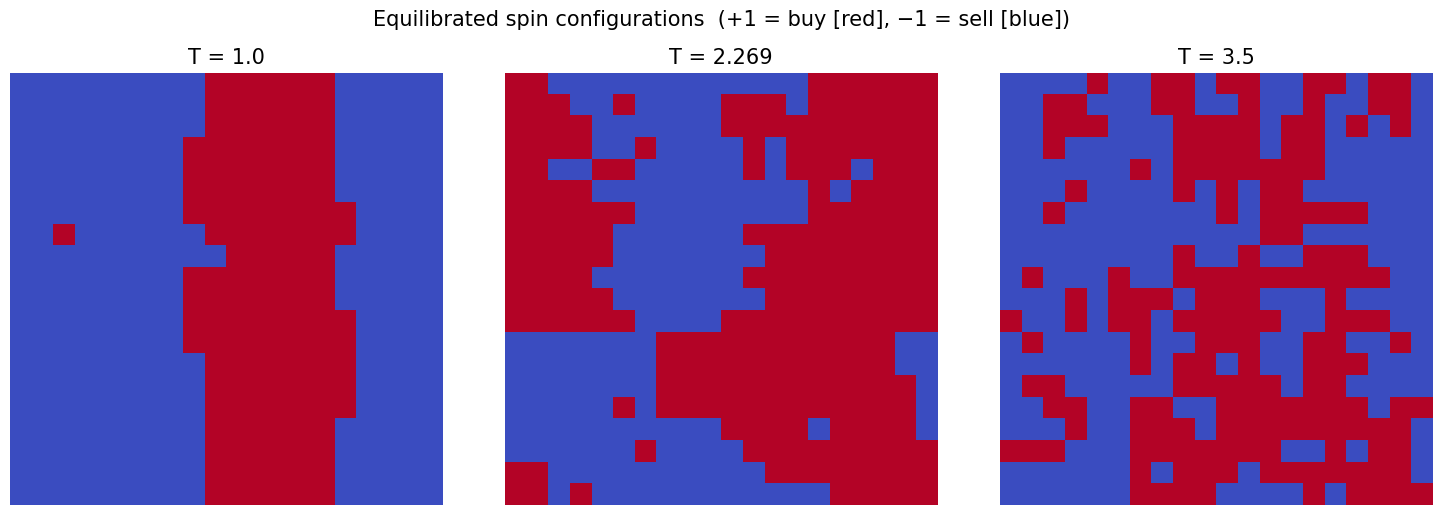

In [6]:
config_temps = [1.0, T_CRITICAL, 3.5]
config_labels = [f"T = {t}" for t in config_temps]

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for ax, T_val, label in zip(axs, config_temps, config_labels):
    canvas = init_canvas(L)
    energy = calculate_ising_energy(canvas, L, J)

    for _ in range(EQUIL_TIME):
        ising_dynamics(canvas, L, T_val)

    ax.imshow(canvas, cmap='coolwarm', vmin=-1, vmax=1)
    ax.set_axis_off()
    ax.set_title(label, fontsize=my_fontsize)

fig.suptitle(
    "Equilibrated spin configurations  (+1 = buy [red], −1 = sell [blue])",
    fontsize=my_fontsize, y=1.02
)
plt.tight_layout()
plt.show()

## Phase transition: |M| and E vs T

In [7]:
print("Running phase-transition sweep...")
print(f"  {len(TEMPS_FULL)} temperatures x {REPLICATES} replicates")
print(f"  Each replicate: {EQUIL_TIME} equil + {RUN_TIME} production steps")

pt_mean_M   = []
pt_std_M    = []
pt_mean_E   = []
pt_std_E    = []

for T_val in TEMPS_FULL:
    rep_M = []
    rep_E = []
    for rep in range(REPLICATES):
        energies, magnetizations = simulate(L, T_val, J)
        rep_M.append(np.mean(np.abs(magnetizations)))
        rep_E.append(np.mean(energies))

    pt_mean_M.append(np.mean(rep_M))
    pt_std_M.append(np.std(rep_M))
    pt_mean_E.append(np.mean(rep_E))
    pt_std_E.append(np.std(rep_E))

    print(f"  T = {T_val:.2f}  |M| = {pt_mean_M[-1]:.3f} ± {pt_std_M[-1]:.3f}")

print("Done.")

Running phase-transition sweep...
  10 temperatures x 5 replicates
  Each replicate: 50 equil + 200 production steps
  T = 1.80  |M| = 0.816 ± 0.124
  T = 1.90  |M| = 0.737 ± 0.200
  T = 2.00  |M| = 0.767 ± 0.176
  T = 2.10  |M| = 0.619 ± 0.269
  T = 2.20  |M| = 0.721 ± 0.084
  T = 2.30  |M| = 0.504 ± 0.170
  T = 2.40  |M| = 0.460 ± 0.158
  T = 2.50  |M| = 0.349 ± 0.093
  T = 2.60  |M| = 0.272 ± 0.118
  T = 2.70  |M| = 0.204 ± 0.038
Done.


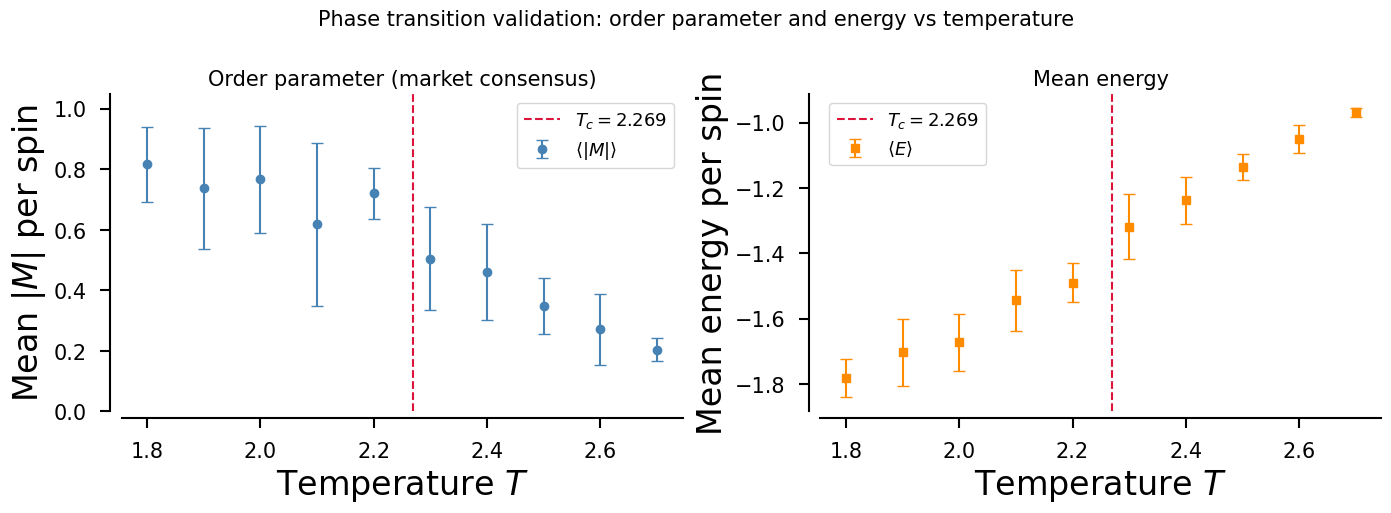

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Mean absolute magnetization vs T
ax = axs[0]
half_frame(ax, 'Temperature $T$', r'Mean $|M|$ per spin', my_fontsize)
ax.errorbar(
    TEMPS_FULL, pt_mean_M, yerr=pt_std_M,
    fmt='o', color='steelblue', markersize=6, capsize=4, linewidth=1.5,
    label=r'$\langle|M|\rangle$'
)
ax.axvline(T_CRITICAL, color='crimson', linestyle='--', linewidth=1.5,
           label=f'$T_c = {T_CRITICAL}$')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=my_fontsize - 2)
ax.set_title('Order parameter (market consensus)', fontsize=my_fontsize)

# Panel 2: Mean energy vs T
ax = axs[1]
half_frame(ax, 'Temperature $T$', 'Mean energy per spin', my_fontsize)
ax.errorbar(
    TEMPS_FULL, pt_mean_E, yerr=pt_std_E,
    fmt='s', color='darkorange', markersize=6, capsize=4, linewidth=1.5,
    label=r'$\langle E \rangle$'
)
ax.axvline(T_CRITICAL, color='crimson', linestyle='--', linewidth=1.5,
           label=f'$T_c = {T_CRITICAL}$')
ax.legend(fontsize=my_fontsize - 2)
ax.set_title('Mean energy', fontsize=my_fontsize)

plt.suptitle(
    'Phase transition validation: order parameter and energy vs temperature',
    fontsize=my_fontsize, y=1.02
)
plt.tight_layout()
plt.show()

## Single run at T_c to sanity check observable functions

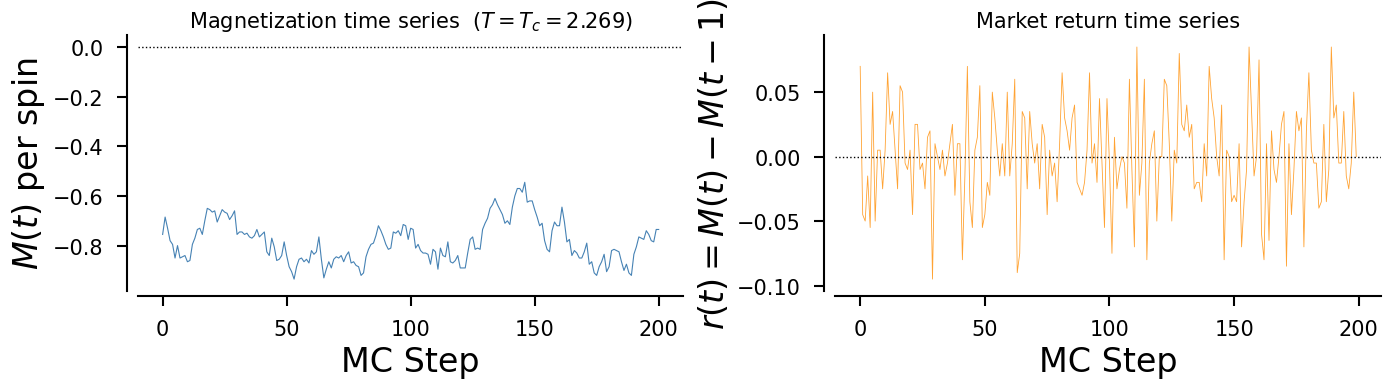

In [9]:
_, mag_test = simulate(L, T_CRITICAL, J)
returns_test = compute_returns(mag_test)

fig, axs = plt.subplots(1, 2, figsize=(14, 4))

ax = axs[0]
half_frame(ax, 'MC Step', '$M(t)$ per spin', my_fontsize)
ax.plot(mag_test, color='steelblue', linewidth=0.8)
ax.axhline(0, color='k', linestyle=':', linewidth=1)
ax.set_title(f'Magnetization time series  ($T = T_c = {T_CRITICAL}$)', fontsize=my_fontsize)

ax = axs[1]
half_frame(ax, 'MC Step', '$r(t) = M(t)-M(t-1)$', my_fontsize)
ax.plot(returns_test, color='darkorange', linewidth=0.6, alpha=0.8)
ax.axhline(0, color='k', linestyle=':', linewidth=1)
ax.set_title('Market return time series', fontsize=my_fontsize)

plt.tight_layout()
plt.show()

## Sweep full temperature range

In [10]:
print("Running susceptibility/volatility sweep...")

sweep_susceptibility_mean = []
sweep_susceptibility_std  = []
sweep_volatility_mean     = []
sweep_volatility_std      = []

for T_val in TEMPS_FULL:
    rep_susc = []
    rep_vol  = []
    for rep in range(REPLICATES):
        _, magnetizations = simulate(L, T_val, J)
        rep_susc.append(compute_susceptibility(magnetizations))
        rep_vol.append(compute_volatility(magnetizations))

    sweep_susceptibility_mean.append(np.mean(rep_susc))
    sweep_susceptibility_std.append(np.std(rep_susc))
    sweep_volatility_mean.append(np.mean(rep_vol))
    sweep_volatility_std.append(np.std(rep_vol))

    print(f"  T = {T_val:.2f}  χ = {sweep_susceptibility_mean[-1]:.4f}  vol = {sweep_volatility_mean[-1]:.4f}")

print("Done.")

Running susceptibility/volatility sweep...
  T = 1.80  χ = 0.0118  vol = 0.0222
  T = 1.90  χ = 0.0369  vol = 0.0256
  T = 2.00  χ = 0.0839  vol = 0.0313
  T = 2.10  χ = 0.0247  vol = 0.0369
  T = 2.20  χ = 0.0273  vol = 0.0391
  T = 2.30  χ = 0.0481  vol = 0.0441
  T = 2.40  χ = 0.0724  vol = 0.0548
  T = 2.50  χ = 0.0676  vol = 0.0549
  T = 2.60  χ = 0.0732  vol = 0.0598
  T = 2.70  χ = 0.0309  vol = 0.0610
Done.


## Susceptibility and Volatility vs T

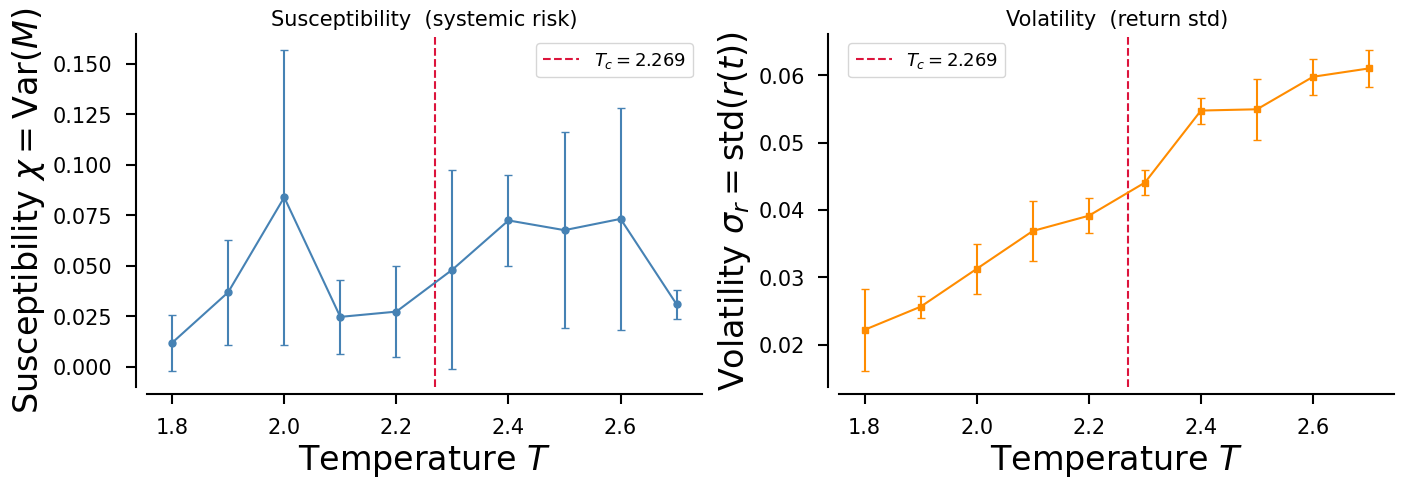

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

ax = axs[0]
half_frame(ax, 'Temperature $T$', r'Susceptibility $\chi = \mathrm{Var}(M)$', my_fontsize)
ax.errorbar(
    TEMPS_FULL, sweep_susceptibility_mean, yerr=sweep_susceptibility_std,
    fmt='o-', color='steelblue', markersize=5, capsize=3, linewidth=1.5
)
ax.axvline(T_CRITICAL, color='crimson', linestyle='--', linewidth=1.5,
           label=f'$T_c = {T_CRITICAL}$')
ax.legend(fontsize=my_fontsize - 2)
ax.set_title('Susceptibility  (systemic risk)', fontsize=my_fontsize)

ax = axs[1]
half_frame(ax, 'Temperature $T$', r'Volatility $\sigma_r = \mathrm{std}(r(t))$', my_fontsize)
ax.errorbar(
    TEMPS_FULL, sweep_volatility_mean, yerr=sweep_volatility_std,
    fmt='s-', color='darkorange', markersize=5, capsize=3, linewidth=1.5
)
ax.axvline(T_CRITICAL, color='crimson', linestyle='--', linewidth=1.5,
           label=f'$T_c = {T_CRITICAL}$')
ax.legend(fontsize=my_fontsize - 2)
ax.set_title('Volatility  (return std)', fontsize=my_fontsize)
plt.tight_layout()
plt.show()

## Collect field-experiment data

In [13]:
print("Running external field experiments...")
print(f"  Temperatures : {TEMPS_FIELD}")
print(f"  Field values : {FIELDS}")

field_data = {}

for T_val in TEMPS_FIELD:
    field_data[T_val] = {}
    for h_val in FIELDS:
        print(f"  T = {T_val},  h = {h_val}")
        rep_mags  = []
        rep_rets  = []
        rep_susc  = []

        for rep in range(REPLICATES):
            _, magnetizations = simulate_field(L, T_val, h_val, J)
            returns = compute_returns(magnetizations)
            rep_mags.append(magnetizations)
            rep_rets.append(returns)
            rep_susc.append(compute_susceptibility(magnetizations))

        field_data[T_val][h_val] = {
            'magnetizations':  rep_mags,
            'returns':         rep_rets,
            'susceptibility':  rep_susc
        }

print("Done.")

Running external field experiments...
  Temperatures : [1.8, 2.269, 3.0]
  Field values : [0.0, 0.5, 1.0]
  T = 1.8,  h = 0.0
  T = 1.8,  h = 0.5
  T = 1.8,  h = 1.0
  T = 2.269,  h = 0.0
  T = 2.269,  h = 0.5
  T = 2.269,  h = 1.0
  T = 3.0,  h = 0.0
  T = 3.0,  h = 0.5
  T = 3.0,  h = 1.0
Done.


## Magnetization time series - 3x3 grid (T x h)

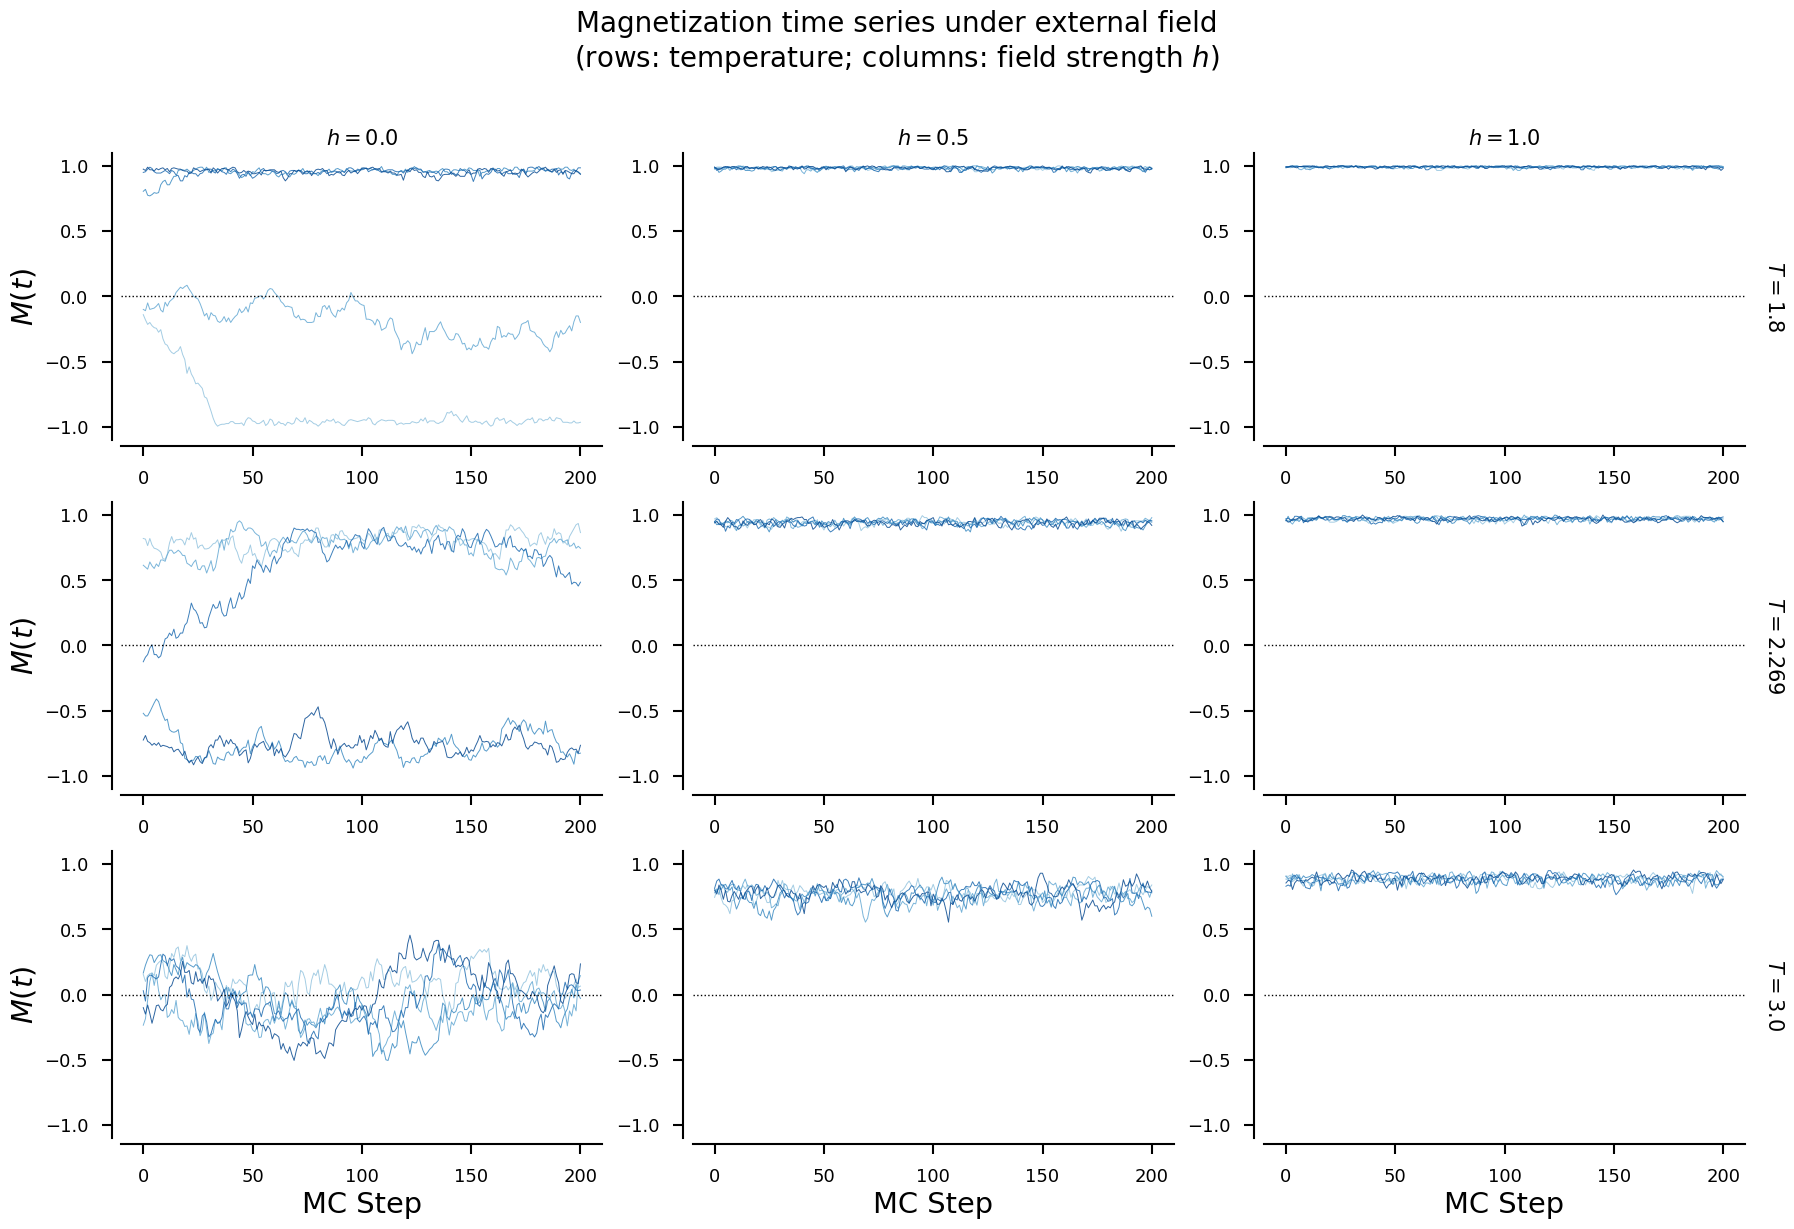

In [14]:
fig, axs = plt.subplots(3, 3, figsize=(18, 12), sharey=True)

colors_rep = plt.cm.Blues(np.linspace(0.4, 0.9, REPLICATES))

for row, T_val in enumerate(TEMPS_FIELD):
    for col, h_val in enumerate(FIELDS):
        ax = axs[row, col]

        x_label = 'MC Step'  if row == 2 else ''
        y_label = '$M(t)$'   if col == 0 else ''
        half_frame(ax, x_label, y_label, my_fontsize - 2)

        for rep_idx, mag in enumerate(field_data[T_val][h_val]['magnetizations']):
            ax.plot(mag, color=colors_rep[rep_idx], linewidth=0.7, alpha=0.85)

        ax.axhline(0, color='k', linestyle=':', linewidth=1)
        ax.set_ylim(-1.1, 1.1)

        if row == 0:
            ax.set_title(f'$h = {h_val}$', fontsize=my_fontsize)
        if col == 2:
            ax.text(
                1.04, 0.5, f'$T = {T_val}$',
                transform=ax.transAxes, rotation=-90,
                va='center', ha='left', fontsize=my_fontsize
            )

plt.suptitle(
    'Magnetization time series under external field\n'
    '(rows: temperature; columns: field strength $h$)',
    fontsize=20, y=1.02
)
plt.tight_layout()
plt.show()

## Summary table

In [15]:
print(f"{'T':>6}  {'|M| mean':>10}  {'|M| std':>9}  "
      f"{'Suscept.':>10}  {'Suscept. std':>13}  "
      f"{'Volatility':>11}  {'Vol std':>8}")
print("-" * 105)

for idx, T_val in enumerate(TEMPS_FULL):
    mean_M   = pt_mean_M[idx]
    std_M    = pt_std_M[idx]
    susc_m   = sweep_susceptibility_mean[idx]
    susc_s   = sweep_susceptibility_std[idx]
    vol_m    = sweep_volatility_mean[idx]
    vol_s    = sweep_volatility_std[idx]

    marker = " T_c" if abs(T_val - T_CRITICAL) < 0.05 else ""
    print(f"{T_val:>6.2f}  {mean_M:>10.4f}  {std_M:>9.4f}  "
          f"{susc_m:>10.5f}  {susc_s:>13.5f}  "
          f"{vol_m:>11.5f}  {vol_s:>8.5f}{marker}")

     T    |M| mean    |M| std    Suscept.   Suscept. std   Volatility   Vol std
---------------------------------------------------------------------------------------------------------
  1.80      0.8164     0.1242     0.01185        0.01383      0.02221   0.00608
  1.90      0.7367     0.2002     0.03686        0.02610      0.02564   0.00165
  2.00      0.7669     0.1757     0.08386        0.07288      0.03126   0.00367
  2.10      0.6185     0.2694     0.02467        0.01823      0.03687   0.00440
  2.20      0.7215     0.0841     0.02727        0.02254      0.03914   0.00257
  2.30      0.5042     0.1700     0.04806        0.04921      0.04406   0.00187 T_c
  2.40      0.4600     0.1579     0.07241        0.02253      0.05475   0.00193
  2.50      0.3489     0.0931     0.06759        0.04854      0.05494   0.00456
  2.60      0.2718     0.1180     0.07317        0.05488      0.05977   0.00269
  2.70      0.2041     0.0378     0.03087        0.00718      0.06101   0.00273
